# DistillRouter — Pipeline

Each step below calls the real, already-built function, on real saved data.

In [15]:
import os, sys, json
from pathlib import Path
from collections import Counter

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run.py").exists())
os.chdir(repo_root)
sys.path.insert(0, str(repo_root))


## Data
Question counts per split, both subjects.

In [16]:
for ds in ["gsm8k", "math"]:
    for split in ["train", "validation", "test", "calibration"]:
        n = sum(1 for _ in open(f"data/processed/{ds}/{split}.jsonl"))
        print(f"{ds:6s} {split:12s} {n}")


gsm8k  train        1000
gsm8k  validation   747
gsm8k  test         500
gsm8k  calibration  20
math   train        1000
math   validation   749
math   test         500
math   calibration  20


## Splits don't overlap
Calls the real check used at data-prep time.

In [17]:
from common.split_integrity import check_dataset_splits, SplitLeakageError

for ds in ["gsm8k", "math"]:
    try:
        check_dataset_splits(ds)
        print(ds, "-> OK, no overlap")
    except SplitLeakageError as e:
        print(ds, "-> OVERLAP:", e)


gsm8k -> OK, no overlap
math -> OK, no overlap


## Oracle — ground truth
Every tier actually executed and scored; the label is the cheapest one that worked.

In [4]:
for ds in ["gsm8k", "math"]:
    counts = Counter(json.loads(l)["routing_label"] for l in open(f"data/oracle/{ds}/train.labels.jsonl"))
    n = sum(counts.values())
    print(f"{ds:6s} n={n:4d}  small={counts['small']:4d}  medium={counts['medium']:4d}  large={counts['large']:4d}")


gsm8k  n= 200  small=  13  medium= 104  large=  83
math   n= 200  small=   5  medium=  39  large= 156


## Teacher


In [19]:
from teacher.base import get_teacher_class
from common.schema import read_jsonl, Example

teacher_cls = get_teacher_class("qwen2.5-3b-v2")
teacher = teacher_cls()

example = read_jsonl(Path("data/processed/gsm8k/validation.jsonl"), Example)[3]
result = teacher.predict(example)
print("question:", example.query)
print("reasoning:", result.routing_reasoning)
print("route:", result.teacher_route)


Loading weights: 100%|██████████| 434/434 [00:00<00:00, 16995.26it/s]


question: Rachel and Sara want to attend a beauty and modeling contest. They both want to buy new pairs of shoes and dresses. Sara buys a pair of shoes which costs $50 and a dress which costs $200. How much should Rachel budget if she wants to spend twice as much as what Sara spent on the pair of shoes and dress?
reasoning: calculating total cost for Sara's items and then doubling it for Rachel's budget based on proportional spending
route: medium


## Teacher accuracy vs oracle
The real comparison function, on the real labeled data.

In [20]:
from evaluation.oracle_check import teacher_accuracy_vs_oracle

result = teacher_accuracy_vs_oracle(["gsm8k", "math"], "train", "v2")
print("overall accuracy:", result["accuracy"])
print("per tier accuracy:", result["per_tier_accuracy"])
print("matched:", result["n_matched"], "/", result["n_oracle_labeled"], "oracle-labeled")


overall accuracy: 0.63
per tier accuracy: {'small': 0.1667, 'medium': 0.5105, 'large': 0.7364}
matched: 400 / 400 oracle-labeled


## Teacher routing distribution
How many questions the teacher assigned to each tier, every split.

In [21]:
import json
from collections import Counter

for ds in ["gsm8k", "math"]:
    print(f"\n=== {ds.upper()} ===")

    for split in ["train", "validation", "test"]:
        counts = Counter(
            json.loads(line)["teacher_route"]
            for line in open(f"data/teacher/{ds}/v2/{split}.jsonl")
        )

        n = sum(counts.values())

        print(
            f"{split:12s} "
            f"n={n:4d} | "
            f"small={counts['small']:4d} ({counts['small']/n*100:5.1f}%) | "
            f"medium={counts['medium']:4d} ({counts['medium']/n*100:5.1f}%) | "
            f"large={counts['large']:4d} ({counts['large']/n*100:5.1f}%)"
        )


=== GSM8K ===
train        n=1000 | small=  79 (  7.9%) | medium= 513 ( 51.3%) | large= 408 ( 40.8%)
validation   n= 747 | small= 131 ( 17.5%) | medium= 363 ( 48.6%) | large= 253 ( 33.9%)
test         n= 500 | small=  77 ( 15.4%) | medium= 241 ( 48.2%) | large= 182 ( 36.4%)

=== MATH ===
train        n=1000 | small=  75 (  7.5%) | medium= 173 ( 17.3%) | large= 752 ( 75.2%)
validation   n= 749 | small=  96 ( 12.8%) | medium= 322 ( 43.0%) | large= 331 ( 44.2%)
test         n= 500 | small=  60 ( 12.0%) | medium= 219 ( 43.8%) | large= 221 ( 44.2%)


## Building the student's training data
The real join and format functions, called directly.

In [22]:
from student.data import build_distillation_dataset, build_sft_records

examples = build_distillation_dataset("gsm8k", "qwen-twostage-reasoning-v5", output_version="v2", split="validation")
print(examples[0])

records = build_sft_records("gsm8k", "qwen-twostage-reasoning-v5", output_version="v2", split="validation")
print(records[0])


[gsm8k/validation] 747 SFT records -> /home/grbdcn/poorna/DistillRouter/data/student/gsm8k/v2/validation.jsonl (skipped 0 other prompt_version, 0 missing example)
DistillationExample(query='Brennan was researching his school project and had to download files from the internet to his computer to use for reference. After downloading 800 files, he deleted 70% of them because they were not helpful. He downloaded 400 more files but again realized that 3/5 of them were irrelevant. How many valuable files was he left with after deleting the unrelated files he downloaded in the second round?', teacher_route='large', routing_reasoning='requires calculating remaining files after multiple deletions and additions, assessing fractions and percentages')
[gsm8k/validation] 747 SFT records -> /home/grbdcn/poorna/DistillRouter/data/student/gsm8k/v2/validation.jsonl (skipped 0 other prompt_version, 0 missing example)
[gsm8k/validation] 747 SFT-format records (sft) -> /home/grbdcn/poorna/DistillRouter/da

## Student training
Real loss, logged during the actual training run.

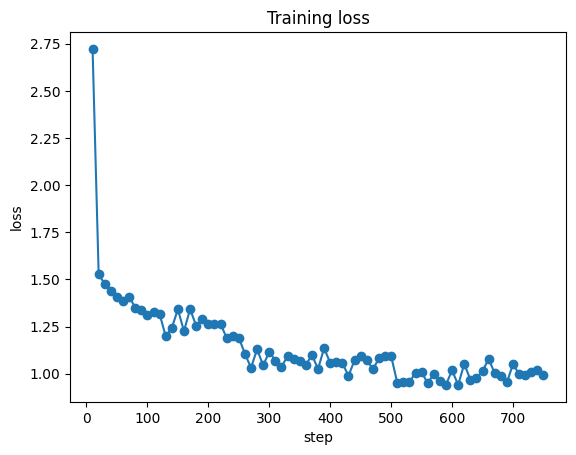

first=2.722 last=0.995


In [23]:
import matplotlib.pyplot as plt

state = json.load(open("checkpoints/student-sft/checkpoint-750/trainer_state.json"))
steps = [e["step"] for e in state["log_history"] if "loss" in e]
losses = [e["loss"] for e in state["log_history"] if "loss" in e]
plt.plot(steps, losses, marker="o")
plt.xlabel("step"); plt.ylabel("loss"); plt.title("Training loss")
plt.show()
print(f"first={losses[0]:.3f} last={losses[-1]:.3f}")


## Checkpoint selection
Real validation results saved by the real selection run, at each epoch.

In [24]:
for ckpt in ["checkpoint-250", "checkpoint-500", "checkpoint-750"]:
    report = json.load(open(f"checkpoints/student-sft/{ckpt}/classification_report.json"))
    print(f"{ckpt}: accuracy={report['accuracy']:.3f}  macro_f1={report['macro_f1']:.3f}")


checkpoint-250: accuracy=0.482  macro_f1=0.353
checkpoint-500: accuracy=0.506  macro_f1=0.395
checkpoint-750: accuracy=0.505  macro_f1=0.413


## Getting a prediction from the trained model
One real call, proving the mechanism.

In [12]:
from evaluation.student_eval import generate_student_predictions

preds = generate_student_predictions("checkpoints/student-best", "gsm8k", "test", max_new_tokens=80)
for p in preds[:3]:
    print(p["query_id"], "->", p["route"])



Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 236/236 [00:00<00:00, 12086.30it/s]

gsm8k-test-588 -> large
gsm8k-test-1214 -> medium
gsm8k-test-57 -> large


## Overall accuracy
The real comparison functions, on the full real saved predictions — not a sample.

In [25]:
from evaluation.student_eval import collect_true_pred_vs_teacher, classification_metrics

def load_predictions(ds, split):
    rows = (json.loads(l) for l in open(f"checkpoints/student-best/eval_{ds}_{split}/predictions.jsonl"))
    return [{"query_id": r["query_id"], "route": r["student_route"]} for r in rows]

def pooled_metrics(split):
    y_true_all, y_pred_all = [], []
    for ds in ["gsm8k", "math"]:
        preds = load_predictions(ds, split)
        y_true, y_pred = collect_true_pred_vs_teacher(preds, ds, "v2", split)
        y_true_all += y_true
        y_pred_all += y_pred
    return classification_metrics(y_true_all, y_pred_all)

validation_result = pooled_metrics("validation")
test_result = pooled_metrics("test")

print("VALIDATION  accuracy:", validation_result["accuracy"], " macro F1:", validation_result["macro_f1"])
print("TEST        accuracy:", test_result["accuracy"], " macro F1:", test_result["macro_f1"])


VALIDATION  accuracy: 0.5047  macro F1: 0.4134
TEST        accuracy: 0.507  macro F1: 0.4096


## Routing distribution
What the teacher chose vs what the student chose, real counts, full test set.

tier       teacher   student
small          137        26
medium         460       349
large          403       625


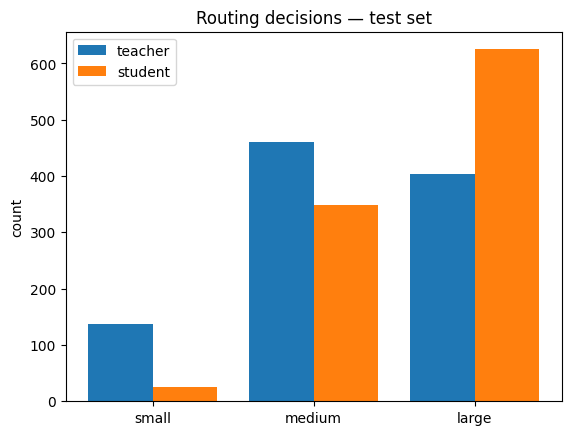

In [26]:
teacher_routes, student_routes = [], []
for ds in ["gsm8k", "math"]:
    for row in (json.loads(l) for l in open(f"checkpoints/student-best/eval_{ds}_test/predictions.jsonl")):
        teacher_routes.append(row["teacher_route"])
        student_routes.append(row["student_route"])

tiers = ["small", "medium", "large"]
t_counts, s_counts = Counter(teacher_routes), Counter(student_routes)

print(f"{'tier':8s}{'teacher':>10s}{'student':>10s}")
for tier in tiers:
    print(f"{tier:8s}{t_counts[tier]:>10d}{s_counts[tier]:>10d}")

x = range(len(tiers))
plt.bar([i - 0.2 for i in x], [t_counts[t] for t in tiers], width=0.4, label="teacher")
plt.bar([i + 0.2 for i in x], [s_counts[t] for t in tiers], width=0.4, label="student")
plt.xticks(list(x), tiers); plt.ylabel("count"); plt.title("Routing decisions — test set"); plt.legend()
plt.show()


## Full report
Precision, recall, F1 per tier, and the confusion matrix.

In [27]:
from evaluation.student_eval import teacher_agreement_report

y_true_all, y_pred_all = [], []
for ds in ["gsm8k", "math"]:
    preds = load_predictions(ds, "test")
    y_true, y_pred = collect_true_pred_vs_teacher(preds, ds, "v2", "test")
    y_true_all += y_true
    y_pred_all += y_pred

full_report = classification_metrics(y_true_all, y_pred_all)
print(json.dumps(full_report, indent=2))


{
  "n_matched": 1000,
  "accuracy": 0.507,
  "macro_precision": 0.5209,
  "macro_recall": 0.4228,
  "macro_f1": 0.4096,
  "per_tier": {
    "small": {
      "precision": 0.5385,
      "recall": 0.1022,
      "f1": 0.1718,
      "support": 137
    },
    "medium": {
      "precision": 0.533,
      "recall": 0.4043,
      "f1": 0.4598,
      "support": 460
    },
    "large": {
      "precision": 0.4912,
      "recall": 0.7618,
      "f1": 0.5973,
      "support": 403
    }
  },
  "confusion_matrix": {
    "labels": [
      "small",
      "medium",
      "large"
    ],
    "matrix": [
      [
        14,
        70,
        53
      ],
      [
        9,
        186,
        265
      ],
      [
        3,
        93,
        307
      ]
    ]
  }
}


## All stages together
Student-vs-teacher accuracy and routing distribution, train, validation, and test

In [28]:
def pooled_metrics(split):
    y_true_all, y_pred_all = [], []
    for ds in ["gsm8k", "math"]:
        preds = load_predictions(ds, split)
        y_true, y_pred = collect_true_pred_vs_teacher(preds, ds, "v2", split)
        y_true_all += y_true
        y_pred_all += y_pred
    return classification_metrics(y_true_all, y_pred_all)

print("accuracy / macro F1 (student vs teacher):")
for split in ["train", "validation", "test"]:
    r = pooled_metrics(split)
    print(f"  {split:12s} accuracy={r['accuracy']:.4f}  macro_f1={r['macro_f1']:.4f}  n={r['n_matched']}")

print()
print("student routing distribution:")
for split in ["train", "validation", "test"]:
    routes = []
    for ds in ["gsm8k", "math"]:
        for row in (json.loads(l) for l in open(f"checkpoints/student-best/eval_{ds}_{split}/predictions.jsonl")):
            routes.append(row["student_route"])
    c = Counter(routes)
    print(f"  {split:12s} small={c['small']:4d}  medium={c['medium']:4d}  large={c['large']:4d}")



accuracy / macro F1 (student vs teacher):
  train        accuracy=0.6975  macro_f1=0.5570  n=2000
  validation   accuracy=0.5047  macro_f1=0.4134  n=1496
  test         accuracy=0.5070  macro_f1=0.4096  n=1000

student routing distribution:
  train        small=  49  medium= 728  large=1223
  validation   small=  33  medium= 540  large= 923
  test         small=  26  medium= 349  large= 625
